In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

1. Sobel Edge Detection on Traffic Sign Image

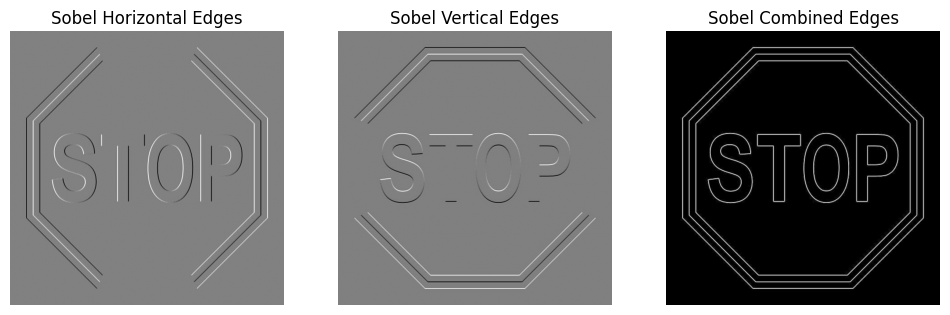

In [ ]:
image = cv2.imread('aa.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found.")
else:
    # Sobel operator for edge detection
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges
    sobel_edges = cv2.magnitude(sobel_x, sobel_y)  # Combined edges (both directions)

    # Plot the results
    plt.figure(figsize=(12, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(sobel_x, cmap='gray')
    plt.title('Sobel Horizontal Edges')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sobel_y, cmap='gray')
    plt.title('Sobel Vertical Edges')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sobel_edges, cmap='gray')
    plt.title('Sobel Combined Edges')
    plt.axis('off')

    plt.show()

2. Prewitt Edge Detection on X-ray Image

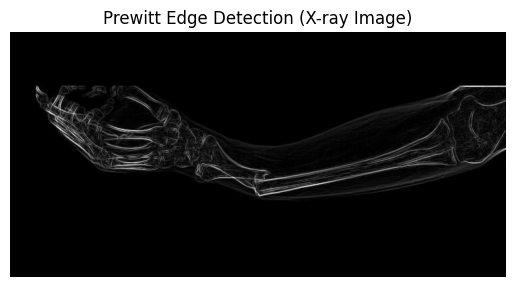

In [ ]:
def prewitt_edge_detection(image):
    # Prewitt kernels
    kernel_x = np.array([[ -1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_y = np.array([[ -1, -1, -1], [ 0, 0, 0], [ 1, 1, 1]])

    # Apply the Prewitt kernels using convolution
    edge_x = cv2.filter2D(image, cv2.CV_64F, kernel_x)  # Changed -1 to cv2.CV_64F for type consistency
    edge_y = cv2.filter2D(image, cv2.CV_64F, kernel_y)  # Changed -1 to cv2.CV_64F for type consistency
    edge_image = cv2.magnitude(edge_x, edge_y)

    return edge_image

# Load the X-ray image
xray_image = cv2.imread('b.jpg', cv2.IMREAD_GRAYSCALE)

if xray_image is None:
    print("Error: Image not found.")
else:
    prewitt_edges = prewitt_edge_detection(xray_image)

    # Plot the results
    plt.imshow(prewitt_edges, cmap='gray')
    plt.title("Prewitt Edge Detection (X-ray Image)")
    plt.axis('off')
    plt.show()

Prewitt vs Sobel: Prewitt operator is more sensitive to horizontal and vertical edges compared to Sobel. The results of Prewitt might not be as smooth as Sobel, especially on noisy images. However, both operators are quite similar.

3. Roberts Edge Detection on Satellite Image

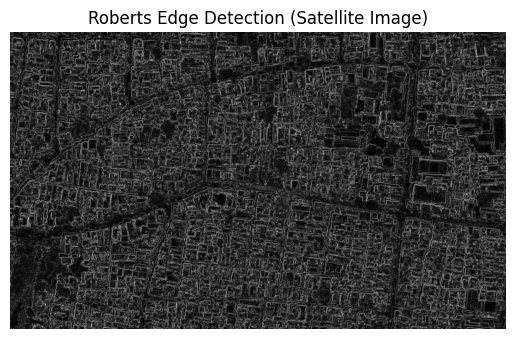

In [ ]:
def roberts_operator(image):
    # Roberts operator kernels
    kernel_x = np.array([[1, 0], [0, -1]])
    kernel_y = np.array([[0, 1], [-1, 0]])

    # Apply the Roberts kernels using convolution
    edge_x = cv2.filter2D(image, cv2.CV_64F, kernel_x)
    edge_y = cv2.filter2D(image, cv2.CV_64F, kernel_y)
    edge_image = cv2.magnitude(edge_x, edge_y)

    return edge_image

# Load the satellite image
satellite_image = cv2.imread('c.jpg', cv2.IMREAD_GRAYSCALE)

if satellite_image is None:
    print("Error: Image not found.")
else:
    roberts_edges = roberts_operator(satellite_image)

    # Plot the results
    plt.imshow(roberts_edges, cmap='gray')
    plt.title("Roberts Edge Detection (Satellite Image)")
    plt.axis('off')
    plt.show()

The Roberts operator is sensitive to noise, especially in real-world satellite images, and may not detect edges as effectively in high-resolution images. It is also susceptible to small variations, so it may not work well on large objects in noisy environments.

4. Laplacian Edge Detection on Surveillance Camera Image

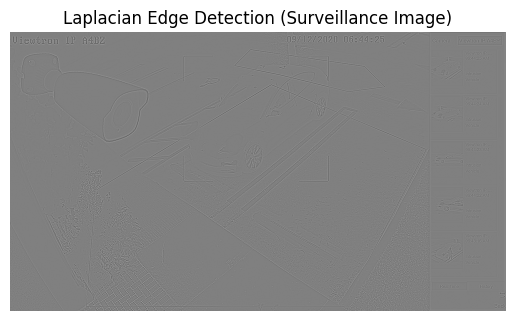

In [ ]:
# Load a surveillance camera image
surveillance_image = cv2.imread('d.jpg', cv2.IMREAD_GRAYSCALE)

# Apply the Laplacian operator
laplacian_edges = cv2.Laplacian(surveillance_image, cv2.CV_64F)

# Plot the result
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian Edge Detection (Surveillance Image)")
plt.axis('off')
plt.show()

The Laplacian operator detects edges without directional bias. It can detect objects at different angles, which is useful for surveillance footage where objects can appear in various orientations.

5. Canny Edge Detection (MRI Scan with Brain Tumor

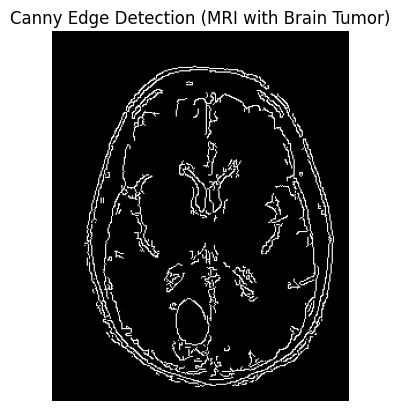

In [ ]:
# Load an MRI image with a brain tumor
mri_image = cv2.imread('e.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Canny edge detection
edges = cv2.Canny(mri_image, 100, 200)

# Plot the result
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection (MRI with Brain Tumor)")
plt.axis('off')
plt.show()

The Canny edge detector is a multi-step algorithm that involves:
1. Gaussian smoothing to reduce noise.
2. Gradient computation to detect edges.
3. Non-maximum suppression to thin out the edges and improve accuracy.

Sobel, Prewitt, Roberts, Laplacian, and Canny are all edge detection techniques, with each having its own strengths and weaknesses for different image types.

Canny edge detection is often preferred for its ability to preserve fine details, especially for medical images (like MRI scans).

Roberts and Prewitt are simpler edge detectors and may struggle with real-world noisy or complex images (e.g., satellite images, traffic signs).

Laplacian is useful for detecting edges regardless of direction.